# Notebook 15 – CNN Image Classification



## 1. What is Image Classification?

**Definition:** Image classification is the task of assigning an image to one class from a predefined set of classes.

For example, if a model receives an image of a shoe, it may predict **Sneaker**.

### Real-world example
An online shopping application can use image classification to identify whether a product image shows a shirt, shoe, bag, or coat.

### AI/ML usage
Image classification is used in:
- Product recognition
- Medical image analysis
- Face and object recognition
- Quality inspection
- Autonomous systems

A CNN is commonly used because images contain spatial patterns such as edges, shapes, and textures.

## 2. What is Fashion-MNIST?

Fashion-MNIST is an image dataset containing grayscale images of clothing items.

Each image has a size of **28 × 28 pixels** and belongs to one of 10 classes:

| Label | Class |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

### Real-world example
Instead of manually checking thousands of clothing photographs, a trained classifier can automatically assign a category to each image.

### AI/ML usage
Fashion-MNIST is useful for learning image classification, CNN architecture, preprocessing, training, and evaluation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 3. Dataset Loading

### Definition
Dataset loading means bringing the image data into the Python program so that the model can learn from it.

For this notebook, `torchvision.datasets.FashionMNIST` downloads and loads Fashion-MNIST.

### Real-world example
In a real company project, the images may come from folders, cloud storage, a database, or an image collection.

### AI/ML usage
A machine learning model cannot learn directly from an external collection of images. The images must first be loaded and converted into a form that the model can process.

In [2]:
transform = transforms.ToTensor()

full_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

len(full_dataset), len(test_dataset)

(60000, 10000)

### Understanding the result

The first value is the number of images available in the training portion and the second value is the number of images in the official test portion.

`ToTensor()` converts each image into a PyTorch tensor and changes pixel values into a numerical range that is easier to use with a neural network.

## 4. Visualization

### Definition
Visualization means displaying examples from the dataset so that we can understand what the model is going to receive.

### Real-world example
Before training a model for medical images, an analyst may inspect sample scans to understand image quality and class differences.

### AI/ML usage
Visualization helps identify:
- Image appearance
- Class differences
- Possible noise
- Data quality problems
- Whether preprocessing is reasonable

### My observation
I want to look at the actual images before training instead of treating the dataset as only numbers.

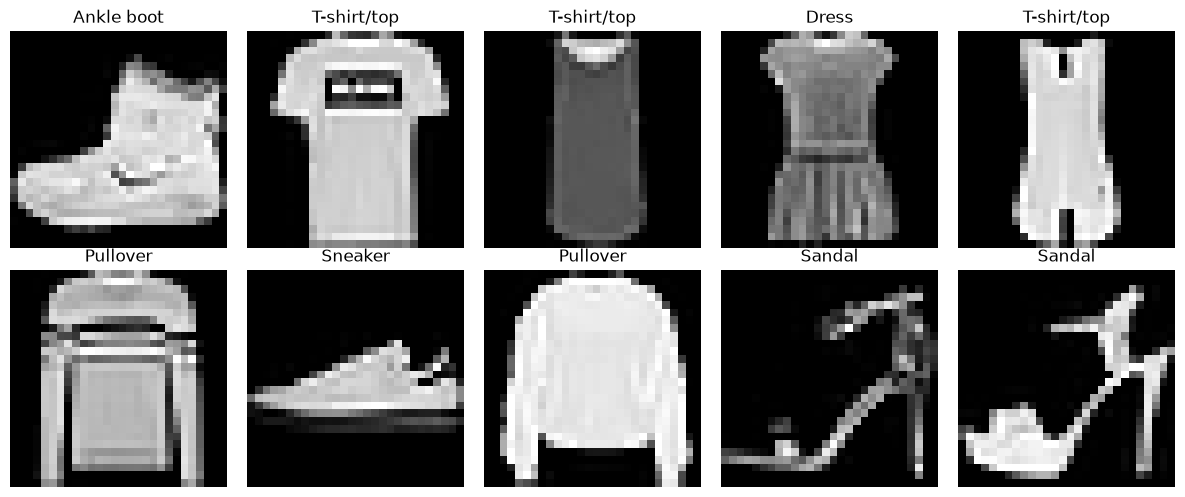

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for index, ax in enumerate(axes.ravel()):
    image, label = full_dataset[index]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Data Normalization

### Definition
Normalization changes the numerical scale of input data so that the values are in a suitable range for neural network training.

For Fashion-MNIST, pixel values are represented between 0 and 1 after `ToTensor()`. We can further standardize them using the dataset mean and standard deviation.

### Why is normalization useful?
Neural networks generally train more smoothly when input values have a consistent scale.

### Real-world example
If one feature is measured in rupees and another in years, their numerical scales can be very different. Scaling helps optimization work more consistently.

### AI/ML usage
Normalization is a common preprocessing step for image models because it can improve training stability and convergence.

In [4]:
mean = full_dataset.data.float().mean() / 255
std = full_dataset.data.float().std() / 255

mean.item(), std.item()

(0.28604060411453247, 0.35302427411079407)

The values above give the approximate mean and standard deviation of the pixel data. I can use them to standardize the images.

For this learning notebook, I will create a normalized transform and reload the datasets with it.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean.item(),), (std.item(),))
])

full_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

## 6. Train/Test Split

### Definition
A dataset is commonly separated into training data and test data.

- **Training data:** used to learn model parameters.
- **Validation data:** used during development to monitor performance.
- **Test data:** used for final evaluation.

### Real-world example
If I build a system to recognize products, I should not evaluate it only on the same images used for learning.

### AI/ML usage
Keeping evaluation data separate helps measure whether the model can generalize to unseen images.

Here I will split the original training portion into:
- 80% training
- 20% validation

The official Fashion-MNIST test set remains separate.

In [6]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

len(train_dataset), len(val_dataset), len(test_dataset)

(48000, 12000, 10000)

## 7. DataLoader

### Definition
A `DataLoader` creates batches of data and provides them to the model during training.

### Why do we use batches?
Instead of sending the complete dataset through the network at once, we process smaller groups called batches.

### Real-world example
Instead of asking a worker to process 50,000 products at one time, products can be handled in manageable groups.

### AI/ML usage
Mini-batches make neural network training practical and allow optimizers to update model parameters repeatedly during an epoch.

In [7]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))

images.shape, labels.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

### Understanding the result

The image batch has a shape similar to:

`[batch_size, channels, height, width]`

For Fashion-MNIST this becomes:

`[64, 1, 28, 28]`

That means:
- 64 images
- 1 grayscale channel
- 28 pixel height
- 28 pixel width

## 8. What is a CNN?

### Definition
A **Convolutional Neural Network**, or CNN, is a neural network designed especially for data with spatial structure such as images.

A CNN learns useful visual patterns automatically.

### Main ideas
- **Convolution:** detects local patterns.
- **Filter/kernel:** small learnable matrix that scans an image.
- **Feature map:** output produced by a convolution.
- **Pooling:** reduces spatial size while retaining useful information.
- **Fully connected layer:** uses learned features to produce class scores.

### Real-world example
In a clothing image, early layers may learn edges. Deeper layers can combine edges into shapes and clothing patterns.

### AI/ML usage
CNNs are widely used for:
- Image classification
- Object detection
- Image segmentation
- Medical image analysis
- Industrial visual inspection

## 9. CNN Architecture

The model used here is intentionally small and beginner-friendly.

### Architecture

**Input → Convolution → ReLU → Max Pooling → Convolution → ReLU → Max Pooling → Flatten → Fully Connected → Output**

### Why each layer is used

**Conv2d:** learns local image features.

**ReLU:** adds non-linearity so the network can learn complex patterns.

**MaxPool2d:** reduces image size and keeps strong features.

**Flatten:** converts feature maps into a one-dimensional vector.

**Linear:** combines learned features for classification.

**Output layer:** produces one score for each of the 10 classes.

### Important point
The values inside convolution and linear layers are learned during training. I do not manually define the best weights.

In [8]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNNClassifier().to(device)
model

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 10. Understanding the Shape Changes

The input image is:

`1 × 28 × 28`

After the first convolution and pooling:

`16 × 14 × 14`

After the second convolution and pooling:

`32 × 7 × 7`

Flattening gives:

`32 × 7 × 7 = 1568`

So the first fully connected layer receives 1568 values.

In [9]:
sample = torch.randn(1, 1, 28, 28).to(device)

with torch.no_grad():
    feature_output = model.features(sample)

feature_output.shape

torch.Size([1, 32, 7, 7])

## 11. Loss Function and Optimizer

### Loss function

The model needs a way to measure how different its predictions are from the correct labels.

For multiclass classification, I will use **Cross Entropy Loss**.

### Optimizer

The optimizer updates the model parameters based on the gradients calculated during backpropagation.

I will use **Adam** because it is a popular optimizer and is beginner-friendly for many neural network problems.

### Real-world example
Loss is like a score showing how far the current answer is from the expected answer. The optimizer uses that information to adjust the model.

### AI/ML usage
The combination of loss + backpropagation + optimizer allows the CNN to learn useful image features automatically.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 12. Training

### Definition
Training is the process of repeatedly showing training images to the model and updating its parameters to reduce the loss.

### One training step

1. Get a batch of images.
2. Perform forward propagation.
3. Calculate the loss.
4. Clear old gradients.
5. Perform backpropagation.
6. Update weights using the optimizer.

### Real-world example
The model makes a prediction, compares it with the correct category, learns from the error, and tries to improve on the next batch.

### AI/ML usage
Training is where the CNN learns the relationship between visual patterns and clothing classes.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## 13. Validation

### Definition
Validation checks the model on data that was not used to update its weights during the current training process.

### Why validation is important
A model can have good training performance but weaker performance on unseen data. Validation helps us monitor this.

### Important difference
During validation, the model should not update its weights.

### AI/ML usage
Validation helps identify issues such as overfitting and helps us decide whether training is improving generalization.

In [12]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## 14. Train the CNN

I will train the model for a small number of epochs so that the notebook remains easy to understand and reasonably quick to run.

The training and validation metrics will be stored so that I can inspect how the model changes over time.

In [13]:
epochs = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(epochs):
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_accuracy = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/5 | Train Loss: 0.4804 | Train Accuracy: 0.8248 | Val Loss: 0.3556 | Val Accuracy: 0.8722
Epoch 2/5 | Train Loss: 0.3142 | Train Accuracy: 0.8854 | Val Loss: 0.2971 | Val Accuracy: 0.8942
Epoch 3/5 | Train Loss: 0.2674 | Train Accuracy: 0.9028 | Val Loss: 0.2618 | Val Accuracy: 0.9047
Epoch 4/5 | Train Loss: 0.2368 | Train Accuracy: 0.9136 | Val Loss: 0.2491 | Val Accuracy: 0.9085
Epoch 5/5 | Train Loss: 0.2159 | Train Accuracy: 0.9194 | Val Loss: 0.2548 | Val Accuracy: 0.9044


### How I interpret the training output

- If training loss decreases, the model is learning from the training data.
- If training accuracy increases, predictions on training images are improving.
- Validation accuracy shows how well the model performs on unseen validation images.
- If training accuracy keeps increasing while validation performance stops improving or decreases, overfitting may be occurring.

The exact values can vary because of hardware, PyTorch versions, and training conditions.

## 15. Visualizing Training and Validation Performance

Plots make it easier to understand whether learning is progressing.

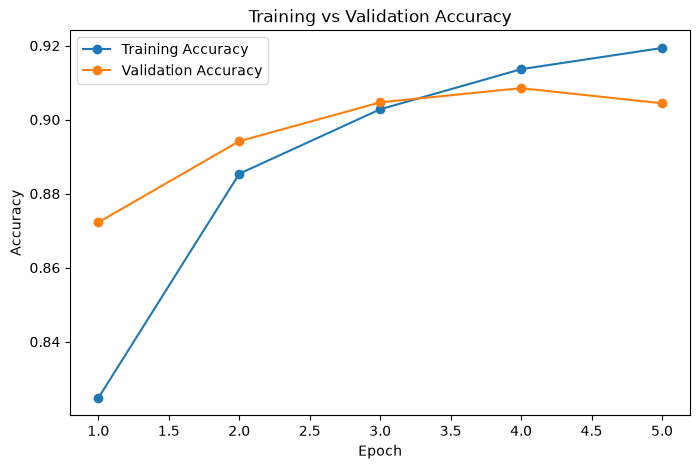

In [14]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

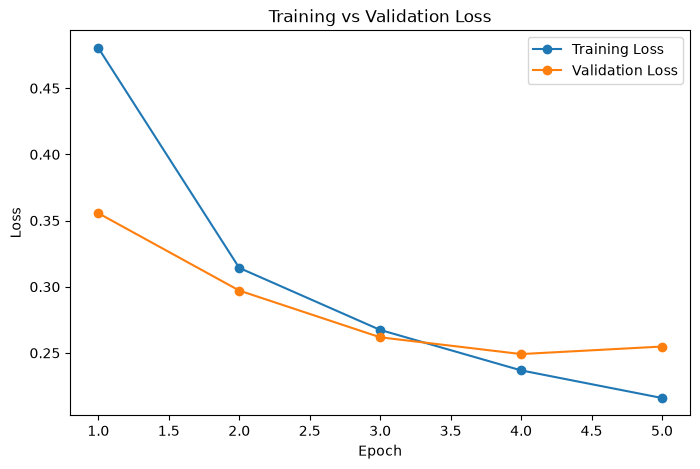

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## 16. Prediction

### Definition
Prediction means using the trained model to estimate the class of an unseen image.

The CNN produces 10 output scores. The class with the highest score is selected as the predicted class.

### Real-world example
A shopping application could send a new clothing image to the trained model and receive a predicted clothing category.

### AI/ML usage
Prediction is the stage where the trained model is used on new data instead of learning from labels.

In [16]:
model.eval()

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    sample_outputs = model(sample_images)

sample_predictions = sample_outputs.argmax(dim=1)

sample_predictions[:10].cpu().numpy(), sample_labels[:10].numpy()

(array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]), array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]))

## 17. Display Correct Predictions

Looking at actual images with their predicted and true labels helps me understand whether the model is learning meaningful visual patterns.

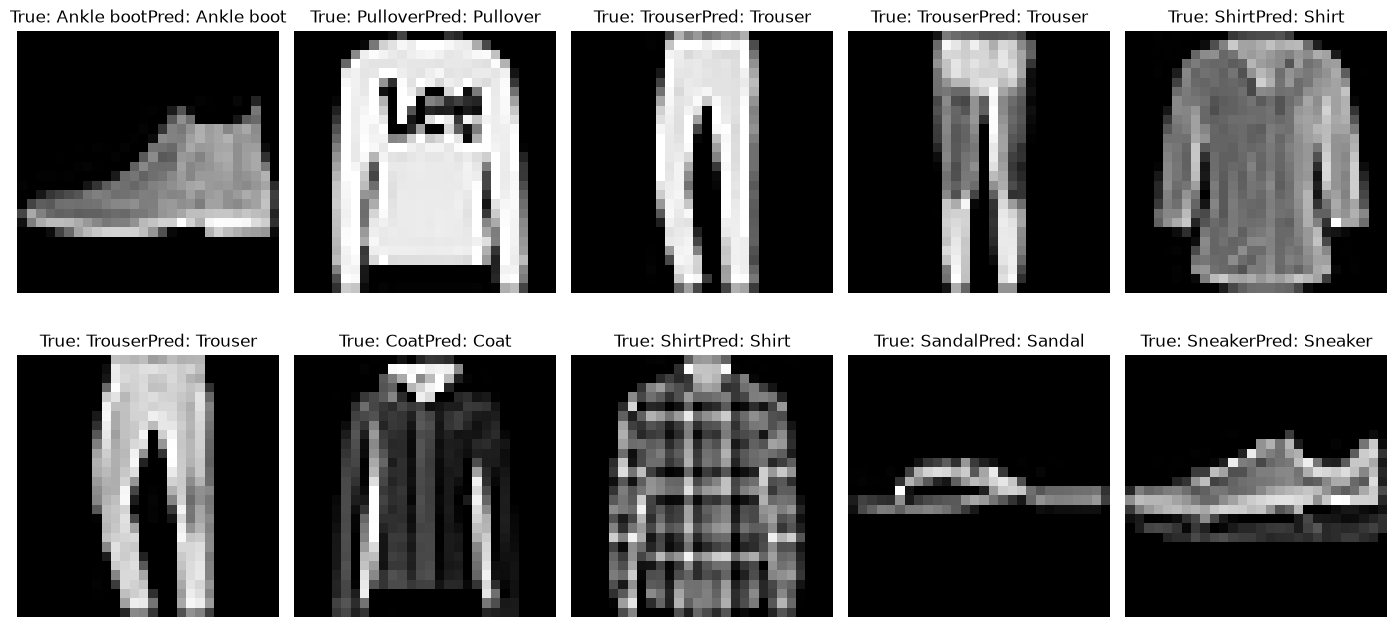

In [18]:
def show_predictions(images, labels, predictions, correct=True, count=10):
    matches = predictions == labels
    indices = torch.where(matches if correct else ~matches)[0][:count]

    plt.figure(figsize=(14, 7))

    for position, index in enumerate(indices):
        plt.subplot(2, 5, position + 1)
        image = images[index].cpu().squeeze().numpy()
        image = image * std.item() + mean.item()
        image = np.clip(image, 0, 1)
        plt.imshow(image, cmap="gray")
        plt.title(
            f"True: {class_names[labels[index].item()]}"
            f"Pred: {class_names[predictions[index].item()]}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(sample_images, sample_labels.to(device), sample_predictions, correct=True)

## 18. Display Incorrect Predictions

Misclassified images are especially useful for learning because they show where the model has difficulty.

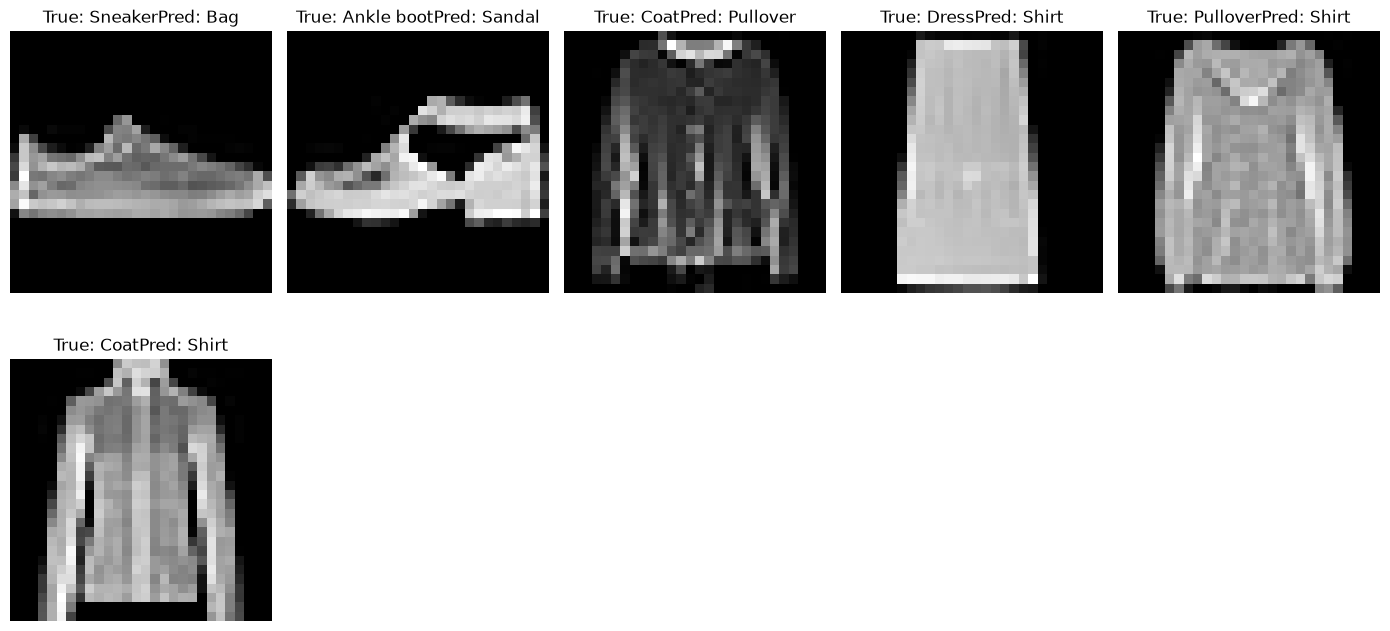

In [19]:
show_predictions(sample_images, sample_labels.to(device), sample_predictions, correct=False)

## 19. Why Did the Model Make Incorrect Predictions?

A CNN does not understand clothing in the same way a human does. It learns numerical patterns from pixels.

Fashion-MNIST contains classes that can look visually similar.

For example:
- Shirt and T-shirt/top can have similar shapes.
- Coat and Pullover can have similar outlines.
- Sandal and Sneaker can share some visual characteristics.

Other reasons for mistakes can include:
- Low image resolution
- Similar object shapes
- Limited visual detail
- Overlapping class characteristics
- The model architecture being relatively small
- The model not learning enough from the available training examples

### Important interpretation

A wrong prediction does not automatically mean that the model is useless. It can show that some classes are harder to separate using the information available in the image.

## 20. Test Set Evaluation

The test set is kept separate from the training and validation data.

This gives us a final estimate of performance on unseen examples.

In [20]:
test_loss, test_accuracy = evaluate(
    model, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2719
Test Accuracy: 0.9021


## 21. Accuracy

### Definition
Accuracy is the proportion of predictions that are correct.

Formula:

**Accuracy = Correct Predictions / Total Predictions**

### Example
If a model correctly predicts 900 out of 1000 images:

**Accuracy = 900 / 1000 = 90%**

### Real-world example
If a product classifier correctly categorizes 900 out of 1000 product images, its accuracy is 90%.

### AI/ML usage
Accuracy is useful when classes are reasonably balanced. Fashion-MNIST has a balanced class distribution, so accuracy is a useful overall metric.

## 22. Confusion Matrix

### Definition
A confusion matrix shows how predictions are distributed across actual and predicted classes.

Rows represent the **true class** and columns represent the **predicted class**.

The diagonal represents correct predictions.

### Real-world example
A confusion matrix can show that a model frequently mistakes shirts for T-shirts.

### AI/ML usage
It helps us understand *which classes* the model confuses rather than giving only one overall accuracy number.

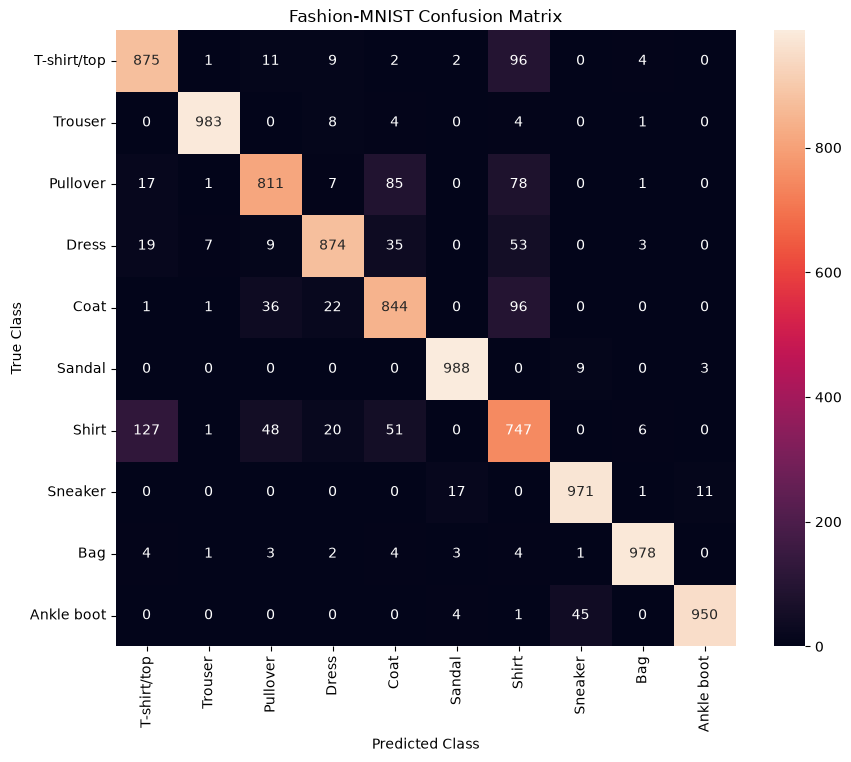

In [21]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Fashion-MNIST Confusion Matrix")
plt.show()

### How I read the confusion matrix

If the value is high on the diagonal, that class is being predicted correctly many times.

If a large value appears away from the diagonal, the model is often confusing one class with another.

For example, if the row for **Shirt** has many values under **T-shirt/top**, the model frequently predicts T-shirt/top when the actual class is Shirt.

## 23. Per-Class Performance

### Definition
Per-class performance measures how well the model handles each individual class.

Important measures include:
- Precision
- Recall
- F1-score

### Precision
Out of everything predicted as a particular class, how much was actually that class?

### Recall
Out of all actual examples of a class, how many did the model correctly identify?

### F1-score
F1-score combines precision and recall into one measure.

### AI/ML usage
Per-class metrics are useful when overall accuracy hides weaknesses in particular categories.

In [22]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

 T-shirt/top     0.8389    0.8750    0.8566      1000
     Trouser     0.9879    0.9830    0.9855      1000
    Pullover     0.8834    0.8110    0.8457      1000
       Dress     0.9278    0.8740    0.9001      1000
        Coat     0.8234    0.8440    0.8336      1000
      Sandal     0.9744    0.9880    0.9811      1000
       Shirt     0.6923    0.7470    0.7186      1000
     Sneaker     0.9464    0.9710    0.9585      1000
         Bag     0.9839    0.9780    0.9809      1000
  Ankle boot     0.9855    0.9500    0.9674      1000

    accuracy                         0.9021     10000
   macro avg     0.9044    0.9021    0.9028     10000
weighted avg     0.9044    0.9021    0.9028     10000



## 24. Finding Misclassified Test Images

Instead of looking at only the numerical metrics, I can inspect actual images that the CNN classified incorrectly.

This connects the evaluation numbers back to the original image data.

In [23]:
all_images = []
all_true_labels = []
all_predicted_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_images.append(images.cpu())
        all_true_labels.append(labels)
        all_predicted_labels.append(predictions.cpu())

all_images = torch.cat(all_images)
all_true_labels = torch.cat(all_true_labels)
all_predicted_labels = torch.cat(all_predicted_labels)

incorrect_indices = torch.where(
    all_true_labels != all_predicted_labels
)[0]

len(incorrect_indices)

979

## 25. Display Some Misclassified Test Images

These examples help answer an important practical question:

**What kind of images does my model struggle with?**

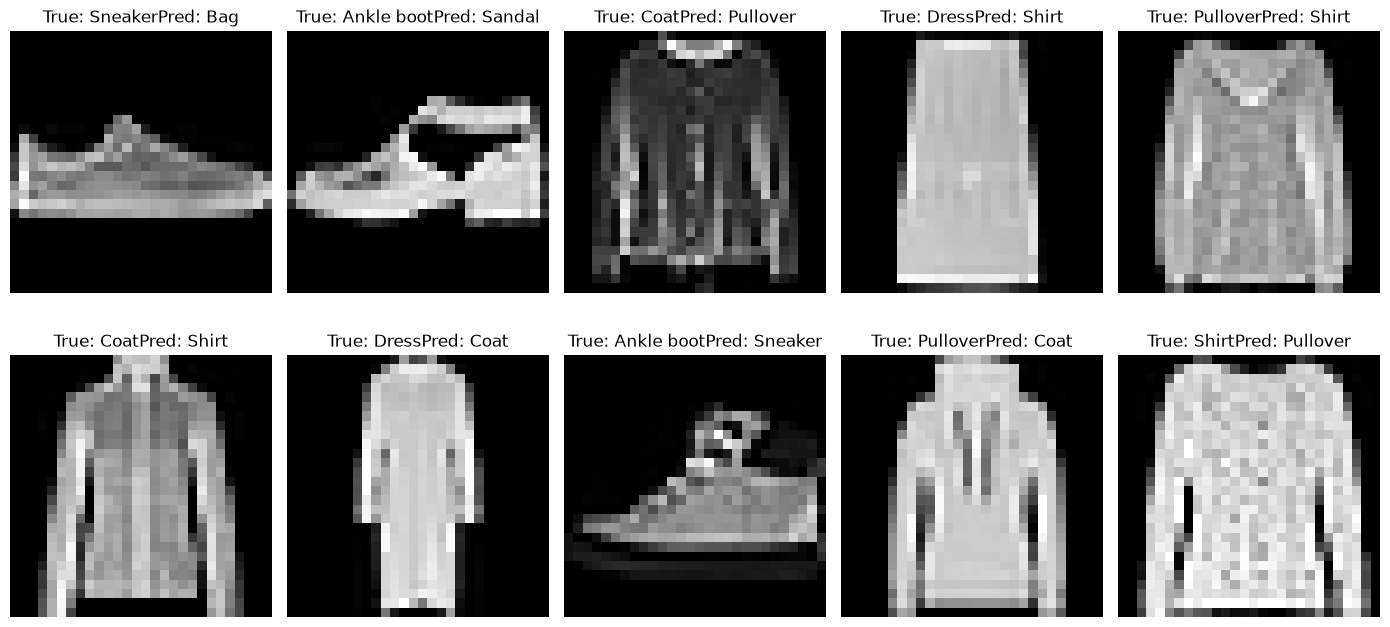

In [25]:
count = min(10, len(incorrect_indices))

plt.figure(figsize=(14, 7))

for position in range(count):
    index = incorrect_indices[position]
    image = all_images[index].squeeze().numpy()
    image = image * std.item() + mean.item()
    image = np.clip(image, 0, 1)

    plt.subplot(2, 5, position + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"True: {class_names[all_true_labels[index].item()]}"
        f"Pred: {class_names[all_predicted_labels[index].item()]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()